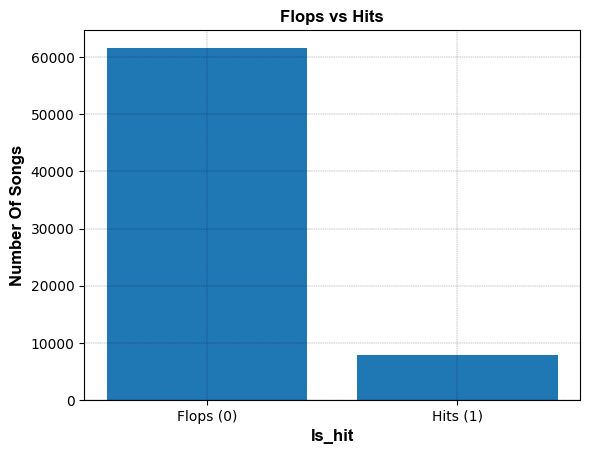

training set rmse = 11.12 
validation set rmse = 12.14   
training set accuracy = 87.98%   
validation set accuracy = 85.69%
test set rmse = 12.39 
test set accuracy = 84.77%
              precision    recall  f1-score   support

           0       0.96      0.87      0.91      9258
           1       0.40      0.71      0.51      1183

    accuracy                           0.85     10441
   macro avg       0.68      0.79      0.71     10441
weighted avg       0.90      0.85      0.86     10441



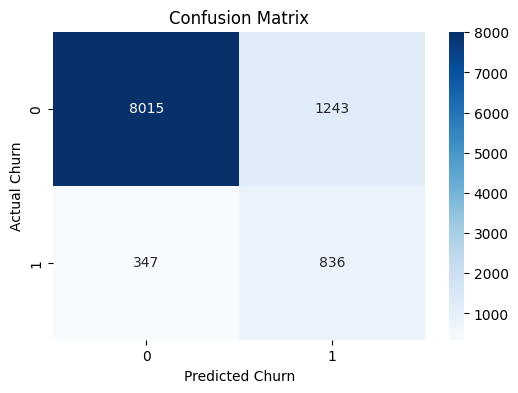

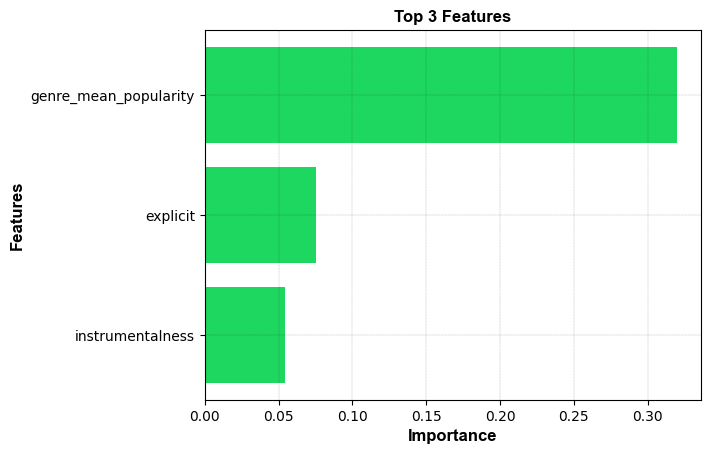

['spotify_2.0_minmax_scaler.joblib']

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn import preprocessing 
import seaborn as sns

df = pd.read_csv('../data/dataset.csv')
df.drop(['Unnamed: 0', 'track_id'] , errors = 'ignore' , inplace = True)
df = df[df['popularity'] != 0]
df = df.drop_duplicates(subset=['track_name'])
df['explicit']=df['explicit'].astype(int)
popularity_threshold = 60
df['is_popular'] = (df['popularity'] >= popularity_threshold).astype(int)
#Creating two indexes for Song Emotion : Banger_Index(cumulative index for danceability,loudness and energy) , Chill_Index(cumulative index for valence and acousticness)
df['banger_index'] = df['danceability'] * (df['loudness'] + 60) * df['energy'] #simce loudness is always negative we add 60 to make it in the range of 0-60
df['chill_index'] = df['valence'] * df['acousticness']
#Plotting the is_popular column to see the the difference between the number of hits vs flops
counts = df['is_popular'].value_counts()
plt.bar(['Flops (0)', 'Hits (1)'],[counts.get(0, 0), counts.get(1, 0)],alpha=1) 
plt.title("Flops vs Hits", fontsize=12,family='arial',fontweight='bold')
plt.xlabel("Is_hit", fontsize=12,family='arial', fontweight = 'bold' )
plt.ylabel("Number Of Songs", fontsize=12,family='arial',fontweight='bold')
plt.grid(linewidth=0.3,linestyle="--",alpha=0.5,color='black')
plt.show()
# Figuring out (Train set + Validation set) and Test set according to year of release
from sklearn.model_selection import train_test_split
train_val_df , test_df = train_test_split(df , test_size = 0.15 , random_state = 42 , stratify=df['is_popular'])
train_val_df = train_val_df.copy()
test_df = test_df.copy()
train_df , val_df = train_test_split(train_val_df , test_size = 0.17 , random_state = 42 , stratify=train_val_df['is_popular'])
train_df = train_df.copy() 
val_df = val_df.copy()
#Target Encoding
genre_means = train_df.groupby('track_genre')['popularity'].mean()
global_mean_popularity = train_df['popularity'].mean()
train_df['genre_mean_popularity'] = train_df['track_genre'].map(genre_means).fillna(global_mean_popularity)
val_df['genre_mean_popularity'] = val_df['track_genre'].map(genre_means).fillna(global_mean_popularity)
test_df['genre_mean_popularity'] = test_df['track_genre'].map(genre_means).fillna(global_mean_popularity)
# Differentiating the Features and Targets
input_cols = ['banger_index','chill_index','key','genre_mean_popularity', 'duration_ms' , 'explicit' , 'danceability' , 'energy' , 'loudness' , 'mode' , 'speechiness' , 'acousticness' , 'instrumentalness' , 'liveness' , 'valence' , 'tempo' , 'time_signature']
target_col1 = ['popularity']
target_col2 = ['is_popular']
train_inputs = train_df[input_cols].copy()
train_target1 = train_df[target_col1]
train_target2 = train_df[target_col2]
val_inputs = val_df[input_cols].copy()
val_target1 = val_df[target_col1]
val_target2 = val_df[target_col2]
test_inputs = test_df[input_cols].copy()
test_target1 = test_df[target_col1]
test_target2 = test_df[target_col2]
# Seperating Numeric
numeric_cols = train_inputs.select_dtypes(include = np.number).columns.tolist()
#Scaling Numeric data
scaler = MinMaxScaler()
scaler.fit(train_inputs[numeric_cols])
train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols] = scaler.transform(test_inputs[numeric_cols])


#Gradient Boosting (Two models one for popularity score and other for is_popular that will output yes/no)

#Training and Evaluating RMSE
def rmse(predictions,targets):
    return np.sqrt(np.mean(np.square( targets.values.ravel() - predictions)))

from xgboost import XGBRegressor , XGBClassifier 
model1 = XGBRegressor(n_jobs = -1 ,  random_state = 42 , learning_rate = 0.01 , max_depth = 7 , 
                      n_estimators = 1000 , colsample_bytree = 0.5 , subsample=0.6 , 
                      min_child_weight = 3 , gamma = 0.5)
model1.fit(train_inputs , train_target1)

train_rmse = rmse(model1.predict(train_inputs),train_target1)
val_rmse = rmse(model1.predict(val_inputs),val_target1)


model2 = XGBClassifier(n_jobs = -1 ,  random_state = 42 , learning_rate = 0.05 , max_depth = 6 ,
                        n_estimators = 300 , colsample_bytree = 0.5 , subsample=0.6 , 
                        min_child_weight = 3 , gamma = 0.5, scale_pos_weight=5 ) 
model2.fit(train_inputs , train_target2)

train_accuracy = model2.score(train_inputs , train_target2)
val_accuracy = model2.score(val_inputs , val_target2)

print(f'training set rmse = {train_rmse:.2f} \nvalidation set rmse = {val_rmse:.2f}   \ntraining set accuracy = {train_accuracy*100:.2f}%   \nvalidation set accuracy = {val_accuracy*100:.2f}%' )
test_rmse = rmse(model1.predict(test_inputs),test_target1)
test_accuracy = model2.score(test_inputs , test_target2)
print(f'test set rmse = {test_rmse:.2f} \ntest set accuracy = {test_accuracy*100:.2f}%')

#In-depth evaluation
from sklearn.metrics import classification_report , confusion_matrix
print(classification_report(test_target2, model2.predict(test_inputs)))

plt.figure(figsize=(6,4))
cm = confusion_matrix(test_target2, model2.predict(test_inputs))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual Churn')
plt.xlabel('Predicted Churn')
plt.show()

#feature importances
importances = pd.Series(model2.feature_importances_ , index=numeric_cols)
top_3_features = importances.sort_values(ascending = True).tail(3)
plt.barh(top_3_features.index , top_3_features.values , color='#1ED760',alpha=1) 
plt.title("Top 3 Features", fontsize=12,family='arial',fontweight='bold')
plt.xlabel("Importance", fontsize=12,family='arial', fontweight = 'bold' )
plt.ylabel("Features", fontsize=12,family='arial',fontweight='bold')
#plt.yticks(["Genre_Mean_Popularity","Explicit","Instrumentalness"])
plt.grid(linewidth=0.2,linestyle="--",alpha=0.5,color='black')
plt.show()
#Saving
import joblib
joblib.dump(model1 , 'spotify_2.0_XGBregressor_model.joblib' )
joblib.dump(model2 , 'spotify_2.0_XGBclassifier_model.joblib' )
joblib.dump(scaler, 'spotify_2.0_minmax_scaler.joblib')










